In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch

In [ ]:
from gluonts.dataset.multivariate_grouper import MultivariateGrouper
from gluonts.dataset.repository.datasets import dataset_recipes, get_dataset
from gluonts.evaluation.backtest import make_evaluation_predictions
from gluonts.evaluation import MultivariateEvaluator

from gluonts.torch.model.crossformer import CrossformerEstimator

In [3]:
dataset = get_dataset("electricity_nips", regenerate=False)

In [4]:
train_grouper = MultivariateGrouper(
    max_target_dim=int(dataset.metadata.feat_static_cat[0].cardinality)
)

test_grouper = MultivariateGrouper(
    num_test_dates=int(len(dataset.test) / len(dataset.train)),
    max_target_dim=int(dataset.metadata.feat_static_cat[0].cardinality),
)

In [5]:
dataset_train = train_grouper(dataset.train)
dataset_test = test_grouper(dataset.test)

In [9]:
estimator = CrossformerEstimator(
    freq=dataset.metadata.freq,
    prediction_length=dataset.metadata.prediction_length,
    context_length=dataset.metadata.prediction_length * 3,
    scaling="std",
    trainer_kwargs=dict(max_epochs=100, devices="auto"),
)

In [ ]:
predictor = estimator.train(
    dataset_train, cache_data=True, shuffle_buffer_length=1024
)

In [13]:
evaluator = MultivariateEvaluator(
    quantiles=(np.arange(20) / 20.0)[1:], target_agg_funcs={"sum": np.sum}
)

In [ ]:
forecast_it, ts_it = make_evaluation_predictions(
    dataset=dataset_test, predictor=predictor, num_samples=100
)
forecasts = list(forecast_it)
targets = list(ts_it)
agg_metric, _ = evaluator(targets, forecasts, num_series=len(dataset_test))

In [15]:
print("CRPS: {}".format(agg_metric["mean_wQuantileLoss"]))
print("ND: {}".format(agg_metric["ND"]))
print("NRMSE: {}".format(agg_metric["NRMSE"]))
print("MSE: {}".format(agg_metric["MSE"]))

CRPS: 0.04494003672902851
ND: 0.05828510130667552
NRMSE: 0.45459982871823046
MSE: 118365.79911495953


In [16]:
print("CRPS-Sum: {}".format(agg_metric["m_sum_mean_wQuantileLoss"]))
print("ND-Sum: {}".format(agg_metric["m_sum_ND"]))
print("NRMSE-Sum: {}".format(agg_metric["m_sum_NRMSE"]))
print("MSE-Sum: {}".format(agg_metric["m_sum_MSE"]))

CRPS-Sum: 0.017025842947381856
ND-Sum: 0.022775214737653548
NRMSE-Sum: 0.02887666386777243
MSE-Sum: 65383052.952380955


In [17]:
  def plot(
      target,
      forecast,
      prediction_length,
      prediction_intervals=(50.0, 90.0),
      color="g",
      fname=None,
  ):
      rows = 4
      cols = 4
      fig, axs = plt.subplots(rows, cols, figsize=(24, 24))
      axx = axs.ravel()
      seq_len, target_dim = target.shape

      ps = [50.0] + [
          50.0 + f * c / 2.0 for c in prediction_intervals for f in [-1.0, +1.0]
      ]
      percentiles_sorted = sorted(set(ps))

      def alpha_for_percentile(p):
          return (p / 100.0) ** 0.3

      legend_handles = None
      legend_labels = None

      for dim in range(0, min(rows * cols, target_dim)):
          ax = axx[dim]

          target[-2 * prediction_length :][dim].plot(ax=ax)
          obs_line = ax.lines[-1]

          ps_data = [
              forecast.quantile(p / 100.0)[:, dim] for p in percentiles_sorted
          ]
          i_p50 = len(percentiles_sorted) // 2

          p50_data = ps_data[i_p50]
          pd.Series(data=p50_data, index=forecast.index).plot(
              color=color, ls="-", ax=ax
          )
          median_line = ax.lines[-1]

          interval_handles = []
          interval_labels = []

          for i in range(len(percentiles_sorted) // 2):
              ptile = percentiles_sorted[i]
              alpha = alpha_for_percentile(ptile)
              interval = 100 - ptile * 2

              patch = ax.fill_between(
                  forecast.index,
                  ps_data[i],
                  ps_data[-i - 1],
                  facecolor=color,
                  alpha=alpha,
                  interpolate=True,
              )
              interval_handles.append(patch)
              interval_labels.append(f"{interval:.1f}% prediction interval")

          if legend_handles is None:
              legend_handles = [obs_line, median_line] + interval_handles[::-1]
              legend_labels = (
                  ["observations", "median prediction"]
                  + interval_labels[::-1]
              )

      axx[0].legend(legend_handles, legend_labels, loc="upper left")

      if fname is not None:
          plt.savefig(fname, bbox_inches="tight", pad_inches=0.05)

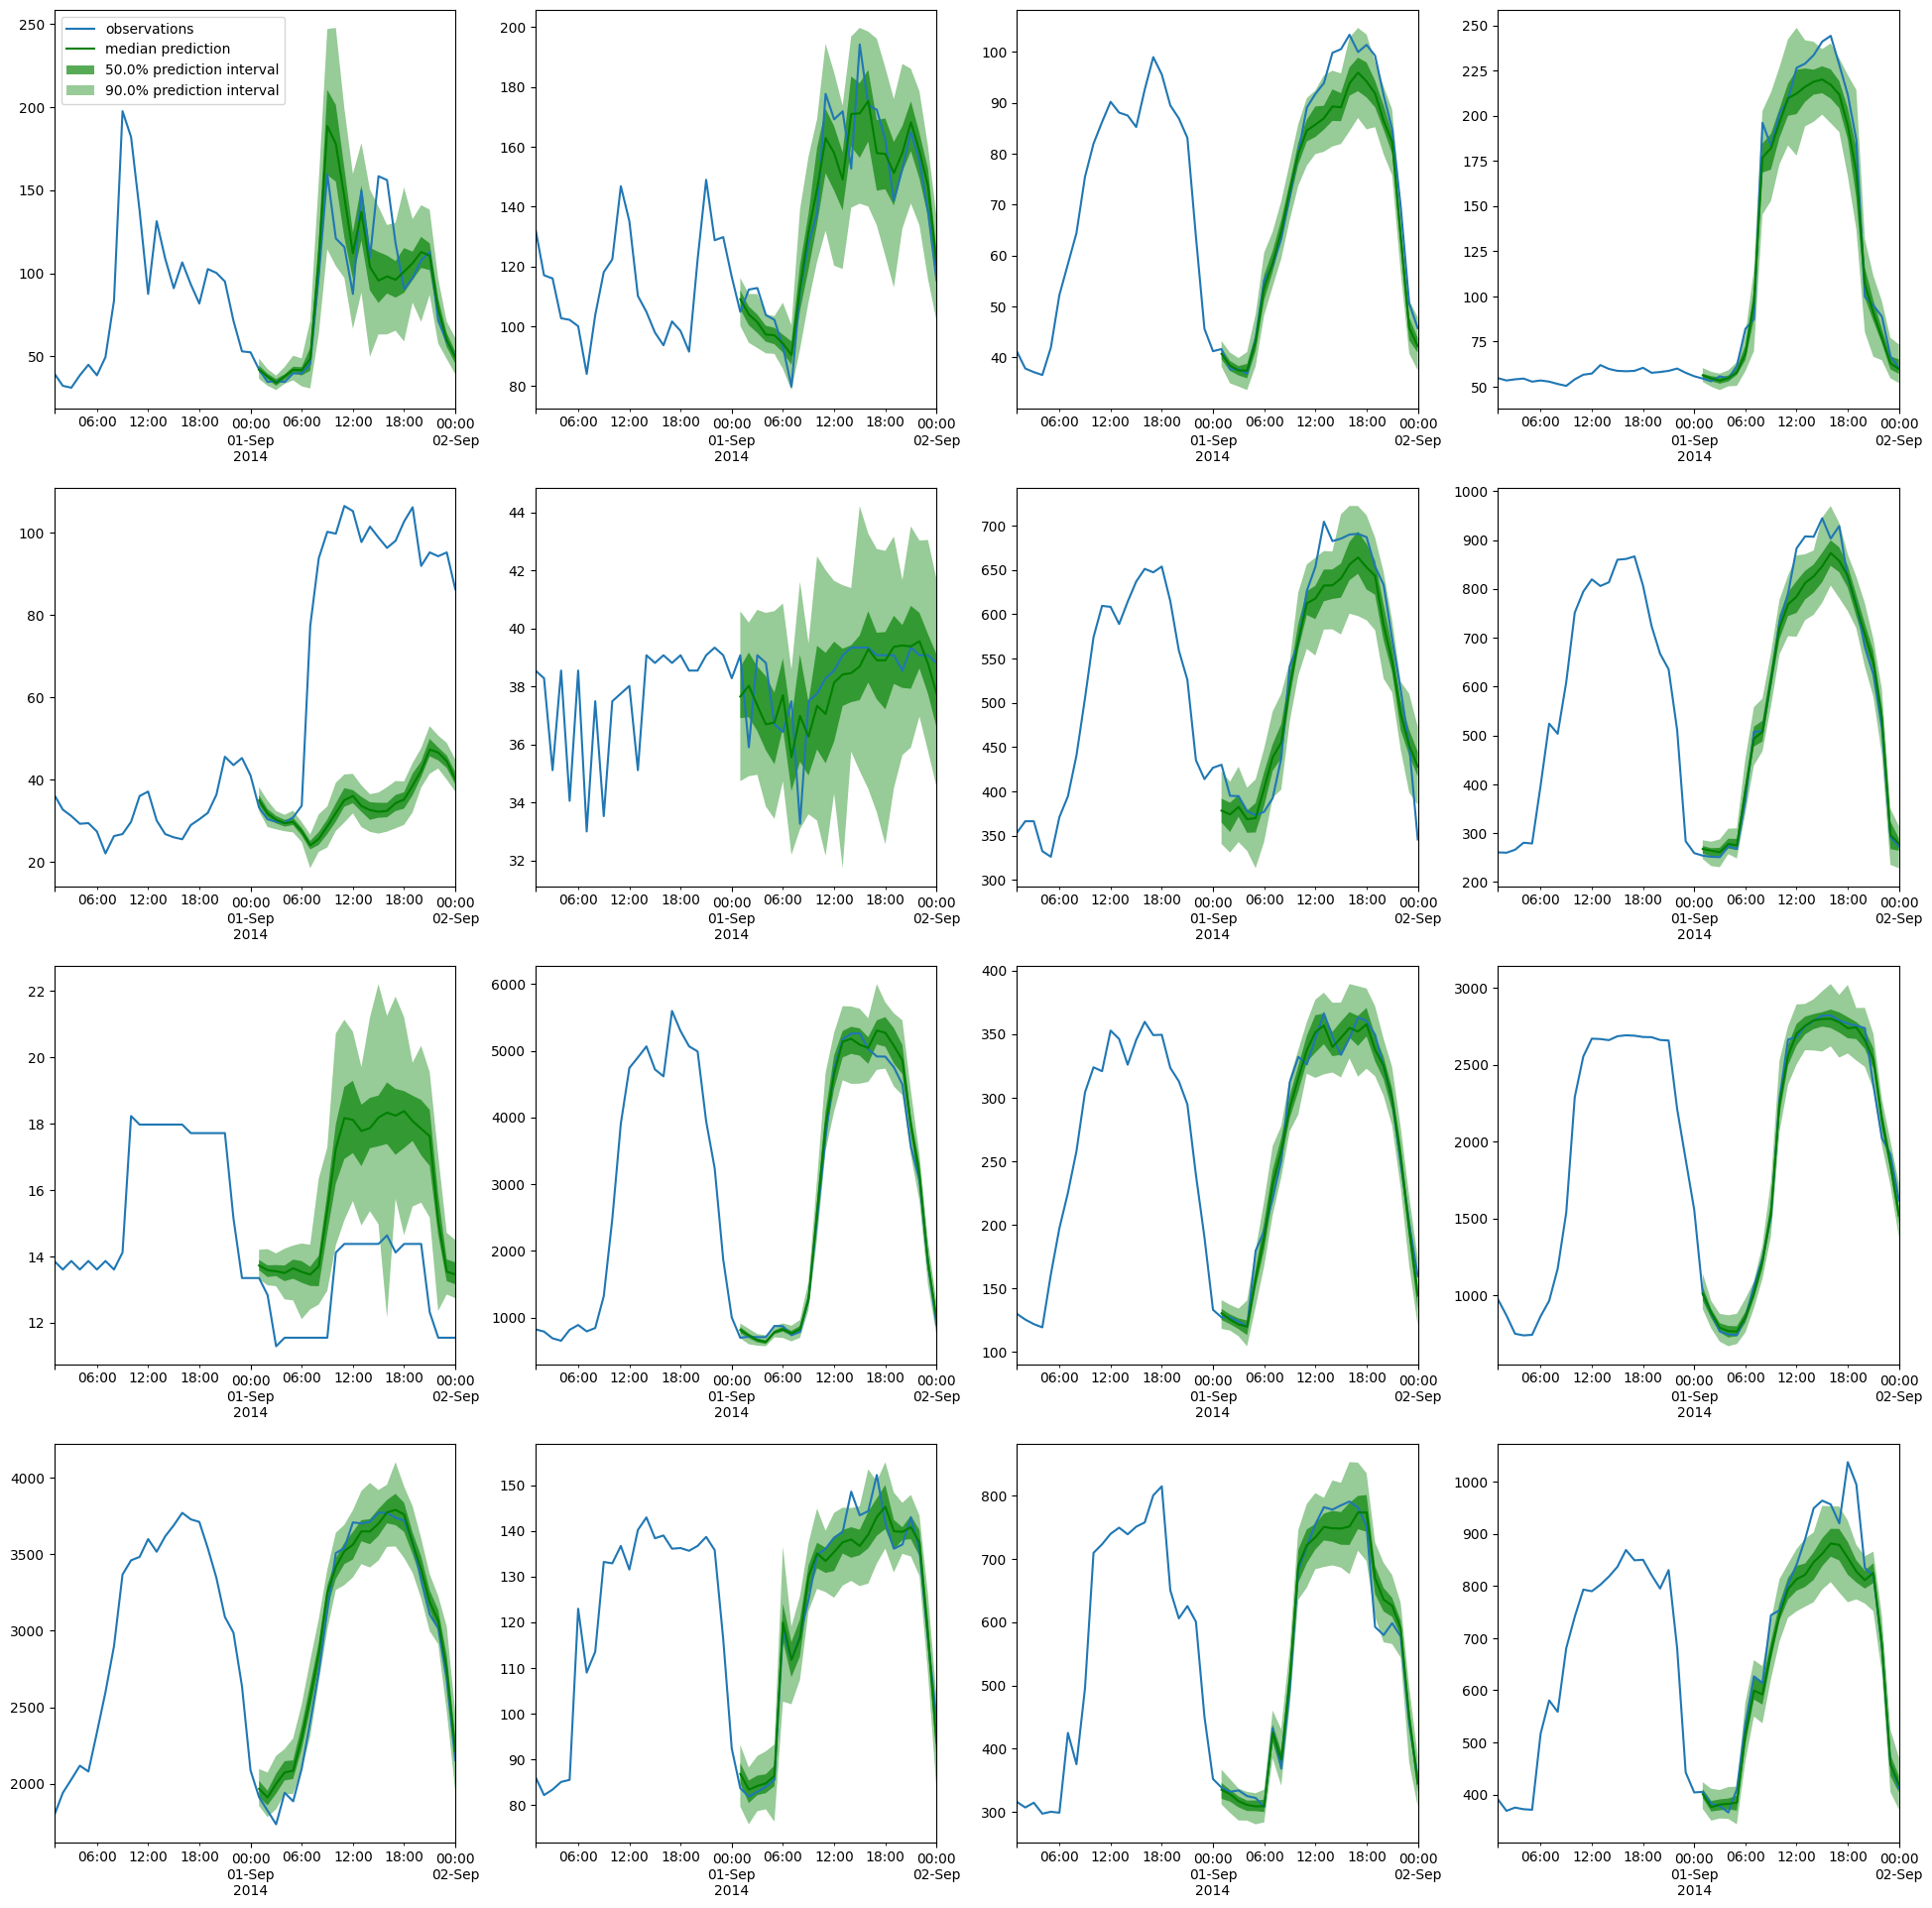

In [18]:
plot(
    target=targets[0],
    forecast=forecasts[0],
    prediction_length=dataset.metadata.prediction_length,
)
plt.show()